In [1]:
import numpy as np
import matplotlib.pyplot as plt


In [2]:
x = np.array([1, 2, 3, 4])
y = np.array([2, 2.8 , 3.6, 4.5])

In [3]:
n = len(x)
# initialize the parameters
w = 0
b = 0
#np.random.seed(42)
#w = np.random.rand()
#b = np.random.rand()

learning_rate = 0.01

# epochs is the number of iterations for training the model
epochs = 100
cost_Values = []
print(f"Initial value: w = {w}")
print(f"Initial value: b = {b}")
print(f"Learning rate: {learning_rate}")
print(f"Epochs: {epochs}")
print("training the model...........")

Initial value: w = 0
Initial value: b = 0
Learning rate: 0.01
Epochs: 100
training the model...........


In [4]:
# Gradient Descent Algorithm
for i in range(epochs):
    # calculate the predicted values
    y_hat = w * x + b
    # calculate the cost function
    cost = 0.5* np.mean((y_hat - y )**2)
    cost_Values.append(cost)
    # calculate the gradients
    dw = (1/n) * np.sum(x * (y_hat - y))
    db = (1/n) * np.sum(y_hat - y)
    # update the parameters
    w = w - learning_rate * dw
    b = b - learning_rate * db
    #new line prediction
    y_hat = w * x + b

    if (i + 1) % 100 == 0 :
        print(f"Epoch {i + 1}: w = {w}, b = {b}, cost = {cost}")


Epoch 100: w = 1.0575418455176155, b = 0.48041277301696655, cost = 0.03792043793280912


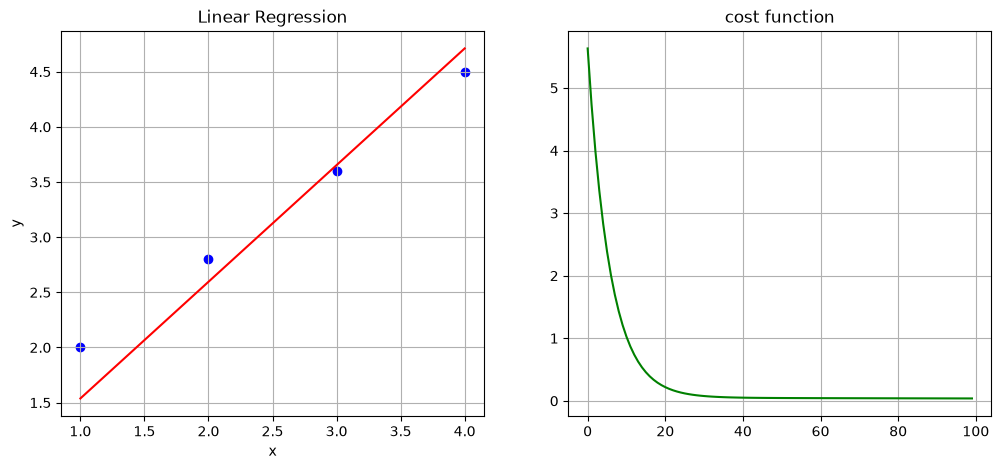

In [5]:
plt.figure (figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.scatter(x, y, color='blue', label='Data points')
plt.plot(x, y_hat, color='red', label='Regression line')
plt.title('Linear Regression')
plt.xlabel('x')
plt.ylabel('y')
plt.grid()

plt.subplot(1, 2, 2)
plt.plot(cost_Values, color='green')
plt.title('cost function')
plt.grid()

In [6]:
import pandas as pd
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score , root_mean_squared_error

In [7]:
data = pd.read_csv('../Salary_Data.csv')

In [8]:
data.head()

,YearsExperience,Salary
0,1.1,39343.0
1,1.3,46205.0
2,1.5,37731.0
3,2.0,43525.0
4,2.2,39891.0


/home/mohamed_hisham/AI/ML-DEPI/venv-Depi/lib/python3.14/site-packages/seaborn/axisgrid.py:2100: UserWarning: The `size` parameter has been renamed to `height`; please update your code.
  warnings.warn(msg, UserWarning)


Text(0.5, 1.0, 'Scatter plot of Years of Experience vs Salary')

<Figure size 1000x600 with 0 Axes>

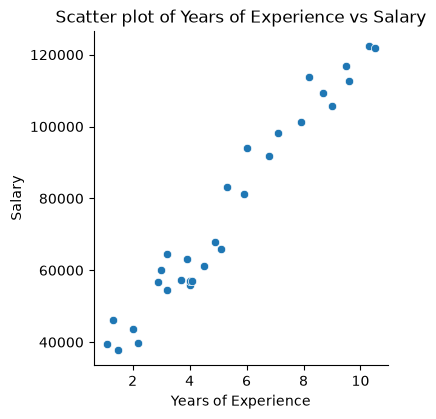

In [9]:
plt.figure(figsize=(10, 6))
sns.pairplot(data , x_vars=['YearsExperience'], y_vars=['Salary'] , size=4 , kind='scatter')
plt.xlabel('Years of Experience')
plt.ylabel('Salary')
plt.title('Scatter plot of Years of Experience vs Salary')

In [10]:
# Split the data into features and target variable
x = data.iloc[:, :-1]
y = data.iloc[:, 1]

In [11]:
x

,YearsExperience
0,1.1
1,1.3
2,1.5
3,2.0
4,2.2
5,2.9
6,3.0
7,3.2
8,3.2
9,3.7


In [12]:
x_train , x_test , y_train , y_test = train_test_split(x, y, test_size=0.2, random_state=10)

In [13]:
y_train

13     57081.0
27    112635.0
12     56957.0
1      46205.0
19     93940.0
14     61111.0
18     81363.0
6      60150.0
11     55794.0
23    113812.0
24    109431.0
28    122391.0
22    101302.0
10     63218.0
26    116969.0
29    121872.0
8      64445.0
25    105582.0
16     66029.0
17     83088.0
0      39343.0
15     67938.0
4      39891.0
9      57189.0
Name: Salary, dtype: float64

In [14]:
lin_reg = LinearRegression()
lin_reg.fit(x_train, y_train)
y_hat = lin_reg.predict(x_train)

Text(0, 0.5, 'Salary')

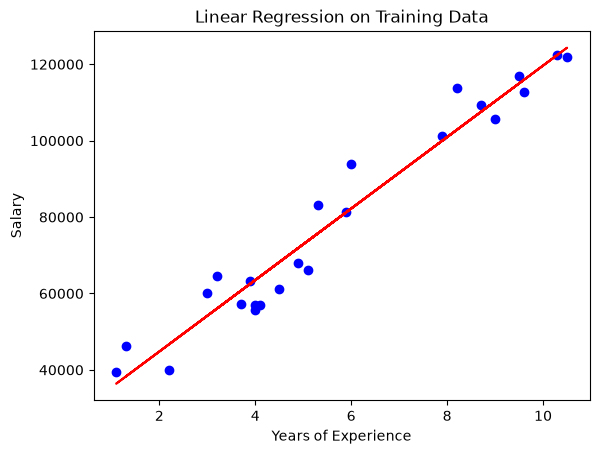

In [15]:
plt.scatter(x_train, y_train, color='blue', label='Data points')
plt.plot(x_train, y_hat, color='red', label='Regression line')
plt.title('Linear Regression on Training Data')
plt.xlabel('Years of Experience')
plt.ylabel('Salary')

In [16]:
y_hat_test = lin_reg.predict(x_test)
y_hat_test

array([89715.76498848, 56031.05821174, 53223.99931368, 40124.39112273,
       44802.8226195 , 92522.82388655])

In [17]:
y_test

20    91738.0
7     54445.0
5     56642.0
2     37731.0
3     43525.0
21    98273.0
Name: Salary, dtype: float64

Text(0, 0.5, 'Salary')

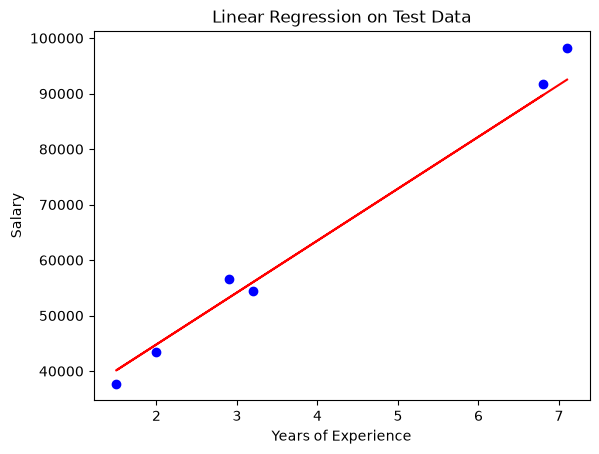

In [18]:
plt.scatter(x_test, y_test, color='blue', label='Data points')
plt.plot(x_test, y_hat_test, color='red', label='Regression line')
plt.title('Linear Regression on Test Data')
plt.xlabel('Years of Experience')
plt.ylabel('Salary')

In [19]:
# calculate the mean squared error
rmse = root_mean_squared_error(y_test, y_hat_test)
print(f"Mean Squared Error: {rmse}")
#this is simply the corelation coefficient, which is a measure of how well the model fits the data. It ranges from 0 to 1, with 1 indicating a perfect fit and 0 indicating no fit at all.
r2 = r2_score(y_test, y_hat_test)
print(f"R-squared: {r2}")

Mean Squared Error: 3128.1895944642365
R-squared: 0.9816423482070253


In [20]:
lin_reg.intercept_

np.float64(26089.09663241673)

In [21]:
lin_reg.coef_

array([9356.86299354])